In [ ]:
print("Svekas, Pasauli!")

In [ ]:
def print_versions():
  import pkg_resources

  packages = ["lambeq","discopy","qiskit","qiskit-aer","qiskit-aer-gpu","qiskit-aer-gpu-cu11","pytket","pytket-qiskit","qiskit_ibm_runtime","cuQuantum-cu12","custatevec-cu12","cutensornet-cu12","cuquantum-python-cu12"]

# cuQuantum (cuStateVec)
  for package in packages:
      try:
          version = pkg_resources.get_distribution(package).version
          print(f"{package}: {version}")
      except pkg_resources.DistributionNotFound:
          print(f"{package}: Not installed")
      except Exception as e:
          print(f"Error: {e}")

print_versions()


from qiskit_aer import AerSimulator
print(AerSimulator().available_devices())
# AerSimulator().available_methods()

In [ ]:
import numpy as np
from tqdm import tqdm
from typing import List, Tuple, Dict

from qiskit_aer import AerSimulator
from pytket.extensions.qiskit.backends.aer import AerBackend
# from qiskit.providers.aer import AerSimulator
# from pytket.extensions.qiskit import AerBackend


from lambeq.backend.grammar import Diagram, Id
from lambeq import (
    AtomicType,
    IQPAnsatz,
    RemoveCupsRewriter,
    SimpleRewriteRule,
    Rewriter,
    UnifyCodomainRewriter,
    DepCCGParser
)

# import depccg
# from lambeq import ( CCGParser, CCGTree, CCGRuleUseError, CCGRule, CCGType,
#                     CCGBankParseError, CCGBankParser, DepCCGParseError )

In [ ]:
parser = DepCCGParser(model='elmo', device=-1) # device=:  -1 == CPU | 0 == GPU | 1 == second GPU

In [ ]:
def create_rewriter():
    # Rule to delete conjunction boxes (“and”, “but”) # just the wire, no box
    conj_rule = SimpleRewriteRule(cod=AtomicType.CONJUNCTION, template=Id(AtomicType.CONJUNCTION))

    # Rule to delete punctuation boxes (commas, quotes, dashes)
    punc_rule = SimpleRewriteRule(cod=AtomicType.PUNCTUATION, template=Id(AtomicType.PUNCTUATION))

    # remove_pp2 = SimpleRewriteRule(cod=AtomicType.PREPOSITIONAL_PHRASE, template=Id(AtomicType.SENTENCE))
    remove_pp = SimpleRewriteRule(cod=AtomicType.PREPOSITIONAL_PHRASE, template=Id(AtomicType.NOUN))

    rewriter = Rewriter(
        [
            'coordination', 'determiner',
            'postadverb', 'preadverb',
            'connector', 'auxiliary',
            'prepositional_phrase',
            'subject_rel_pronoun',
            'object_rel_pronoun',
        ]
    )
    rewriter.add_rules(remove_pp, punc_rule, conj_rule)
    return rewriter


ansatz = IQPAnsatz(
    {AtomicType.SENTENCE: 1, AtomicType.NOUN: 1, AtomicType.PREPOSITIONAL_PHRASE: 0},
    n_layers=2,
    n_single_qubit_params=3,
)

rewriter = create_rewriter()
remove_cups = RemoveCupsRewriter()
unify = UnifyCodomainRewriter(output_type=AtomicType.SENTENCE)

In [ ]:
diagram = parser.sentence2diagram("Alice loves Bob")
diagram = diagram.normal_form().pregroup_normal_form()

diagram = RemoveCupsRewriter()(diagram)
diagram = UnifyCodomainRewriter(output_type=AtomicType.SENTENCE)(diagram)

circuit = ansatz(diagram)

# 0 : 100%|██████████| 1/1 [00:00<00:00, 815.54it/s]


<class 'lambeq.backend.grammar.Diagram'>
<class 'lambeq.backend.quantum.Diagram'>


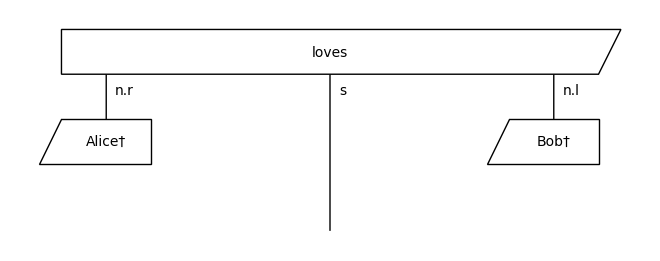

In [10]:
print(type(diagram))
print(type(circuit))
diagram.draw()

In [ ]:

def testing_lambeq_DepCCG(sentence: str):
    d = parser.sentence2diagram(sentence)
    print(type(d))
    diagram_removed_cups = remove_cups(d)
    print(type(diagram_removed_cups))
    diagram_noraml_form = diagram_removed_cups.normal_form()
    print(type(diagram_noraml_form))
    diagram_pregroup_normal_form = diagram_noraml_form.pregroup_normal_form()
    print(type(diagram_pregroup_normal_form))
    diagram_unified = unify(diagram_pregroup_normal_form)
    print(type(diagram_unified))
    diagram_ansatz = ansatz(diagram_unified)
    print(type(diagram_ansatz))

testing_lambeq_DepCCG("Alice loves Bob")

In [ ]:
## Using DipCCG instead of BobcatParser

# sudo apt update
# sudo apt install pkg-config libfreetype6-dev libpng-dev
# sudo apt install python3.10-dev

# pip install "cython<3.0" "numpy<2.0" "setuptools<70.0.0" wheel matplotlib
# pip install depccg --no-build-isolation
# pip install "ipython<8.13"


# pip install allennlp==2.10.1 allennlp-models==2.10.1
# pip install spacy==3.5.1

# pip install googledrivedownloader
# depccg_en download elmo

# numpy-1.26.4

In [ ]:
# allennlp 2.10.1 requires spacy<3.4,>=2.1.0, but you have spacy 3.8.11 which is incompatible.
# pytket 2.12.0 requires numpy>=1.26.4, but you have numpy 1.23.5 which is incompatible.
# pytket-qiskit 0.66.0 requires numpy>=1.26.4, but you have numpy 1.23.5 which is incompatible.

In [ ]:
# (qnlp_3_10) green@DESKTOP-5DCJBRK:~/QNLPModelTraining$ pip install numpy==1.23.5
# Collecting numpy==1.23.5
#   Downloading numpy-1.23.5-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
# Downloading numpy-1.23.5-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
#    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 3.7 MB/s  0:00:04
# Installing collected packages: numpy
#   Attempting uninstall: numpy
#     Found existing installation: numpy 1.26.4
#     Uninstalling numpy-1.26.4:
#       Successfully uninstalled numpy-1.26.4
# ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
# allennlp 2.10.1 requires spacy<3.4,>=2.1.0, but you have spacy 3.8.11 which is incompatible.
# pytket 2.12.0 requires numpy>=1.26.4, but you have numpy 1.23.5 which is incompatible.
# pytket-qiskit 0.66.0 requires numpy>=1.26.4, but you have numpy 1.23.5 which is incompatible.
# Successfully installed numpy-1.23.5

In [ ]:
# git config --global user.name "Green-255"
# git config --global user.email "naglis.kontautas04@gmail.com"

In [ ]:
# For CUDA Toolkit installation on ubuntu
# green@DESKTOP-5DCJBRK:/downloads$ export PATH=$PATH:/usr/local/cuda-13.1/bin
# green@DESKTOP-5DCJBRK:/downloads$ export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/usr/local/cuda-13.1/lib64

In [ ]:
# UNIX username: green
# UNIX password: baiktabaki